In [1]:
# Cell 1: imports and environment
import os, random, json, math, gc
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
from PIL import Image, ImageEnhance, ImageFilter
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available(): print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.13.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [2]:
# Cell 2: configuration
PROJECT_DIR = Path(r'C:\Users\sujal\OneDrive\Documents\praccodes\solar-filament-project')
IMAGE_DIR = PROJECT_DIR / 'dataset' / 'kaggle' / 'train' / 'images'
MASK_DIR = PROJECT_DIR / 'dataset' / 'masks'
CHECKPOINT_DIR = PROJECT_DIR / 'checkpoints'
OUTPUT_DIR = PROJECT_DIR / 'outputs'
MODEL_NAME = 'nvidia/mit-b2'
IMAGE_SIZE = 640  # Change only this value to 512 when desired
BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 4
EPOCHS = 50
SEED = 42
EARLY_STOPPING_PATIENCE = 8
ENCODER_LR = 1e-5
DECODER_LR = 1e-4
WEIGHT_DECAY = 1e-4
LOSS_TYPE = 'dice_bce'  # 'dice_bce' or 'focal_dice'
NUM_WORKERS = 0 if os.name == 'nt' else min(4, os.cpu_count() or 1)
THRESHOLD = 0.5
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True); OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
seed_everything()
print(f'Configuration: {MODEL_NAME}, {IMAGE_SIZE}x{IMAGE_SIZE}, batch={BATCH_SIZE}, accumulation={GRADIENT_ACCUMULATION_STEPS}')

Configuration: nvidia/mit-b2, 640x640, batch=1, accumulation=4


In [8]:
# Cell 3: paths and dataset verification
IMAGE_EXTENSIONS = {'.png', '.jpg', '.jpeg', '.tif', '.tiff'}
image_files = sorted([p for p in IMAGE_DIR.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS])
mask_files = sorted([p for p in MASK_DIR.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS])
image_names = {p.stem for p in image_files}; mask_names = {p.stem for p in mask_files}
matched_names = sorted(image_names & mask_names)
images_without_masks = sorted(image_names - mask_names)
masks_without_images = sorted(mask_names - image_names)
print(f'Images: {len(image_files)}'); print(f'Masks: {len(mask_files)}'); print(f'Matched pairs: {len(matched_names)}')
print(f'Images without masks: {len(images_without_masks)}'); print(f'Masks without images: {len(masks_without_images)}')
assert len(matched_names) == 707, 'Expected 707 matched pairs.'
assert not images_without_masks and not masks_without_images, 'Dataset contains unmatched files.'
image_paths = {p.stem: p for p in image_files}
mask_paths = {p.stem: p for p in mask_files}
records = [{'name': n, 'image': image_paths[n], 'mask': mask_paths[n]} for n in matched_names]

Images: 707
Masks: 707
Matched pairs: 707
Images without masks: 0
Masks without images: 0


In [9]:
# Cell 4: deterministic 565/71/71 split
split_records = records.copy(); random.Random(SEED).shuffle(split_records)
train_records = split_records[:565]; val_records = split_records[565:636]; test_records = split_records[636:707]
assert (len(train_records), len(val_records), len(test_records)) == (565, 71, 71)
print('Train:', len(train_records), 'Validation:', len(val_records), 'Test:', len(test_records))
print('Split is deterministic with seed', SEED)

Train: 565 Validation: 71 Test: 71
Split is deterministic with seed 42


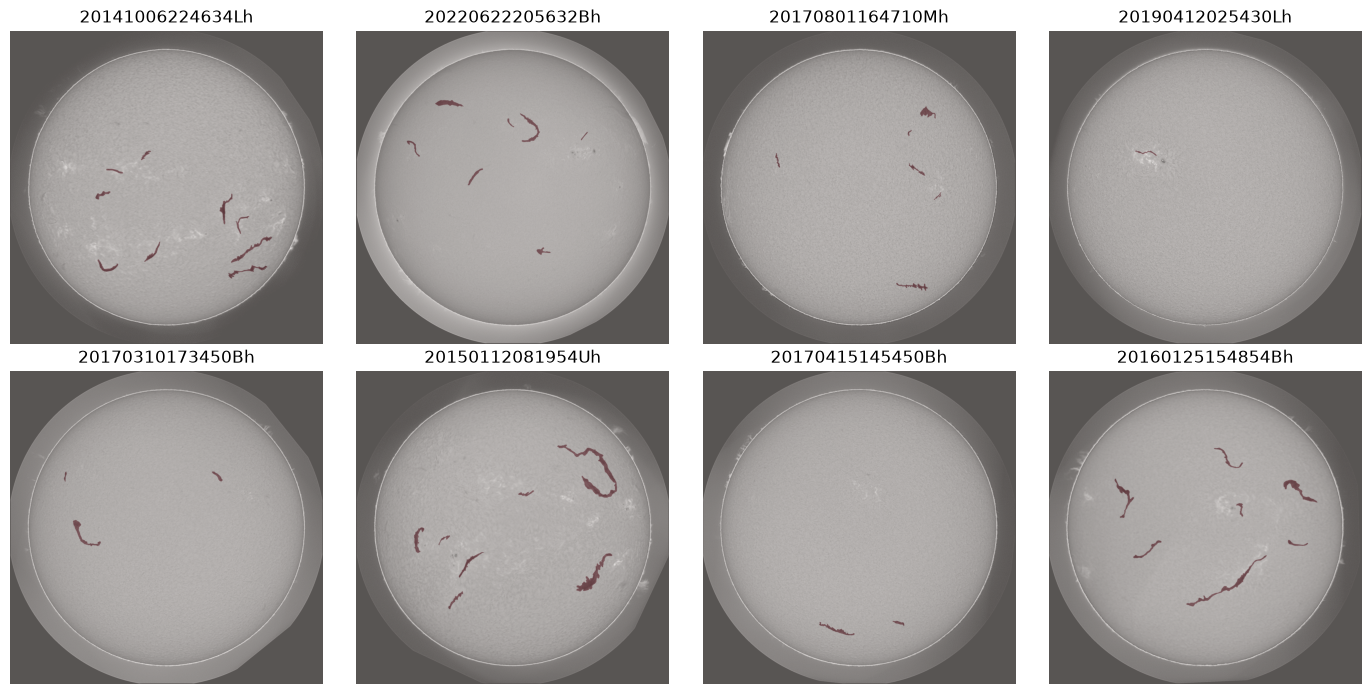

In [10]:
# Cell 5: inspect representative dataset samples
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, record in zip(axes.ravel(), train_records[:8]):
    image = Image.open(record['image']).convert('RGB'); mask = np.array(Image.open(record['mask']).convert('L')) > 127
    ax.imshow(image); ax.imshow(mask, cmap='Reds', alpha=0.35); ax.set_title(record['name'][:16]); ax.axis('off')
plt.tight_layout(); plt.show()

In [11]:
# Cell 6: augmentation and PyTorch Dataset
processor = SegformerImageProcessor.from_pretrained(MODEL_NAME)
def augment_pair(image, mask):
    if random.random() < 0.5: image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT); mask = mask.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
    if random.random() < 0.5: image = image.transpose(Image.Transpose.FLIP_TOP_BOTTOM); mask = mask.transpose(Image.Transpose.FLIP_TOP_BOTTOM)
    quarter_turns = random.randrange(4)
    if quarter_turns: image = image.rotate(90 * quarter_turns, expand=True); mask = mask.rotate(90 * quarter_turns, expand=True)
    angle = random.uniform(-8, 8)
    image = image.rotate(angle, resample=Image.Resampling.BILINEAR, fillcolor=0); mask = mask.rotate(angle, resample=Image.Resampling.NEAREST, fillcolor=0)
    if random.random() < 0.5: image = ImageEnhance.Brightness(image).enhance(random.uniform(0.9, 1.1))
    if random.random() < 0.5: image = ImageEnhance.Contrast(image).enhance(random.uniform(0.9, 1.1))
    return image, mask
class SolarFilamentDataset(Dataset):
    def __init__(self, records, image_size, training=False): self.records, self.image_size, self.training = records, image_size, training
    def __len__(self): return len(self.records)
    def __getitem__(self, index):
        record = self.records[index]
        image = Image.open(record['image']).convert('RGB')
        mask = Image.open(record['mask']).convert('L')
        if self.training: image, mask = augment_pair(image, mask)
        image = image.resize((self.image_size, self.image_size), Image.Resampling.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), Image.Resampling.NEAREST)
        encoded = processor(images=np.asarray(image), do_resize=False, return_tensors='pt')
        pixel_values = encoded['pixel_values'].squeeze(0)
        labels = torch.from_numpy((np.asarray(mask) > 127).astype(np.int64))
        return {'pixel_values': pixel_values, 'labels': labels, 'name': record['name']}

preprocessor_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

c:\Users\sujal\OneDrive\Documents\praccodes\solar-filament-project\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sujal\.cache\huggingface\hub\models--nvidia--mit-b2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [12]:
# Cell 7: DataLoaders
def make_loaders(image_size):
    train_ds = SolarFilamentDataset(train_records, image_size, True)
    val_ds = SolarFilamentDataset(val_records, image_size, False)
    test_ds = SolarFilamentDataset(test_records, image_size, False)
    common = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
    return train_ds, val_ds, test_ds, DataLoader(train_ds, shuffle=True, drop_last=False, **common), DataLoader(val_ds, shuffle=False, **common), DataLoader(test_ds, shuffle=False, **common)
train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = make_loaders(IMAGE_SIZE)
print(len(train_loader), len(val_loader), len(test_loader))

565 71 71


In [13]:
# Cell 8: load SegFormer-B2 with exactly two labels
id2label = {0: 'background', 1: 'filament'}; label2id = {'background': 0, 'filament': 1}
model = SegformerForSemanticSegmentation.from_pretrained(MODEL_NAME, num_labels=2, id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True).to(DEVICE)
assert model.config.num_labels == 2
print(model.config.architectures, model.config.num_labels)

config.json:   0%|          | 0.00/70.0k [00:00<?, ?B/s]

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `1000`.


pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 99.0MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.bias                                         | UNEXPECTED | 
classifier.weight                                       | UNEXPECTED | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.classifier.bias                             | MISSING    | 
decode_head.batch_norm.weight                           | MISSING    | 
decode_head.batch_norm.num_batches_tracked              | MISSING    | 
decode_head.linear_fuse.weight                          | MISSING    | 
decode_head.batch_norm.running_mean                     | MISSING    | 
decode_head.classifier.weight                           | MISSING    | 
decode_head.batch_norm.bias                             

['SegformerForImageClassification'] 2


model.safetensors: reconstructing file:   0%|          |  0.00B / 98.9MB            

model.safetensors: downloading bytes:           |  0.00B            

In [14]:
# Cell 9: forward-pass helper
def forward_logits(batch):
    outputs = model(pixel_values=batch['pixel_values'].to(DEVICE))
    return F.interpolate(outputs.logits, size=batch['labels'].shape[-2:], mode='bilinear', align_corners=False)
batch = next(iter(val_loader)); logits = forward_logits(batch)
print('Image shape:', tuple(batch['pixel_values'].shape)); print('Mask shape:', tuple(batch['labels'].shape)); print('Logits shape:', tuple(logits.shape))

c:\Users\sujal\OneDrive\Documents\praccodes\solar-filament-project\.venv\Lib\site-packages\transformers\image_processing_backends.py:135: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  image = torch.from_numpy(image).contiguous()


Image shape: (1, 3, 640, 640)
Mask shape: (1, 640, 640)
Logits shape: (1, 2, 640, 640)


In [15]:
# Cell 10: Dice, BCE, and optional Focal+Dice losses
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6): super().__init__(); self.smooth = smooth
    def forward(self, logits, targets):
        probabilities = torch.softmax(logits, dim=1)[:, 1]
        targets = targets.float(); dims = (1, 2)
        intersection = (probabilities * targets).sum(dims)
        return (1 - ((2 * intersection + self.smooth) / (probabilities.sum(dims) + targets.sum(dims) + self.smooth))).mean()
dice_loss = DiceLoss()
bce_loss = nn.BCEWithLogitsLoss()
def focal_loss(logits, targets, gamma=2.0):
    foreground_logits = logits[:, 1]
    bce = F.binary_cross_entropy_with_logits(foreground_logits, targets.float(), reduction='none')
    probabilities = torch.sigmoid(foreground_logits)
    modulating = torch.where(targets.bool(), 1 - probabilities, probabilities) ** gamma
    return (modulating * bce).mean()
def compute_loss(logits, targets):
    if LOSS_TYPE == 'dice_bce': return 0.7 * dice_loss(logits, targets) + 0.3 * bce_loss(logits[:, 1], targets.float())
    if LOSS_TYPE == 'focal_dice': return 0.7 * dice_loss(logits, targets) + 0.3 * focal_loss(logits, targets)
    raise ValueError(f'Unsupported LOSS_TYPE: {LOSS_TYPE}')

In [16]:
# Cell 11: full-dataset segmentation metrics
def confusion_counts(logits, targets):
    predictions = (torch.softmax(logits, dim=1)[:, 1] >= THRESHOLD); targets = targets.bool()
    return ((predictions & targets).sum().item(), (predictions & ~targets).sum().item(), (~predictions & targets).sum().item())
def metrics_from_counts(tp, fp, fn):
    return {'dice': 2*tp / max(2*tp + fp + fn, 1), 'iou': tp / max(tp + fp + fn, 1), 'precision': tp / max(tp + fp, 1), 'recall': tp / max(tp + fn, 1)}
def accumulate_metrics(loader, training=False):
    tp = fp = fn = 0
    for batch in loader:
        with torch.set_grad_enabled(training): logits = forward_logits(batch)
        a, b, c = confusion_counts(logits, batch['labels'].to(DEVICE)); tp += a; fp += b; fn += c
    return metrics_from_counts(tp, fp, fn)

In [17]:
# Cell 12: AdamW parameter groups and scheduler
def make_optimizer_scheduler():
    encoder, decoder = [], []
    for name, parameter in model.named_parameters():
        if not parameter.requires_grad: continue
        (decoder if 'decode_head' in name else encoder).append(parameter)
    optimizer = torch.optim.AdamW([{'params': encoder, 'lr': ENCODER_LR}, {'params': decoder, 'lr': DECODER_LR}], weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, threshold=1e-3, min_lr=1e-7)
    return optimizer, scheduler
optimizer, scheduler = make_optimizer_scheduler()
scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

In [18]:
# Cell 13: training function
def train_one_epoch():
    model.train(); optimizer.zero_grad(set_to_none=True); total_loss = 0; tp = fp = fn = 0
    for step, batch in enumerate(train_loader):
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            logits = forward_logits(batch); loss = compute_loss(logits, batch['labels'].to(DEVICE)) / GRADIENT_ACCUMULATION_STEPS
        scaler.scale(loss).backward()
        if (step + 1) % GRADIENT_ACCUMULATION_STEPS == 0 or step + 1 == len(train_loader):
            scaler.unscale_(optimizer); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); scaler.step(optimizer); scaler.update(); optimizer.zero_grad(set_to_none=True)
        total_loss += loss.item() * GRADIENT_ACCUMULATION_STEPS
        a, b, c = confusion_counts(logits.detach(), batch['labels'].to(DEVICE)); tp += a; fp += b; fn += c
    return total_loss / len(train_loader), metrics_from_counts(tp, fp, fn)

In [19]:
# Cell 14: validation function
@torch.no_grad()
def validate():
    model.eval(); total_loss = 0; tp = fp = fn = 0
    for batch in val_loader:
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()): logits = forward_logits(batch); total_loss += compute_loss(logits, batch['labels'].to(DEVICE)).item()
        a, b, c = confusion_counts(logits, batch['labels'].to(DEVICE)); tp += a; fp += b; fn += c
    return total_loss / len(val_loader), metrics_from_counts(tp, fp, fn)

In [20]:
# Cell 15: checkpoint utilities
CHECKPOINT_PATH = CHECKPOINT_DIR / 'segformer_b2_best.pt'
HISTORY_PATH = OUTPUT_DIR / 'segformer_b2_history.csv'
def save_checkpoint(epoch, best_dice):
    torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict(), 'scheduler_state_dict': scheduler.state_dict(), 'best_validation_dice': best_dice, 'configuration': {'loss_type': LOSS_TYPE, 'batch_size': BATCH_SIZE, 'grad_accumulation': GRADIENT_ACCUMULATION_STEPS}, 'image_size': IMAGE_SIZE, 'model_name': MODEL_NAME, 'seed': SEED}, CHECKPOINT_PATH)
def load_checkpoint(path=CHECKPOINT_PATH):
    checkpoint = torch.load(path, map_location=DEVICE, weights_only=False); model.load_state_dict(checkpoint['model_state_dict']); optimizer.load_state_dict(checkpoint['optimizer_state_dict']); scheduler.load_state_dict(checkpoint['scheduler_state_dict']); return checkpoint

In [22]:
# Cell 16: one-batch VRAM and training test with explicit 512 fallback
def rebuild_for_size(size):
    global IMAGE_SIZE, train_ds, val_ds, test_ds, train_loader, val_loader, test_loader, model, optimizer, scheduler, scaler
    IMAGE_SIZE = size; train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = make_loaders(IMAGE_SIZE)
    model = SegformerForSemanticSegmentation.from_pretrained(MODEL_NAME, num_labels=2, id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True).to(DEVICE)
    optimizer, scheduler = make_optimizer_scheduler(); scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())
def one_batch_test():
    global IMAGE_SIZE, model
    try:
        model.train(); batch = next(iter(train_loader)); optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()): logits = forward_logits(batch); loss = compute_loss(logits, batch['labels'].to(DEVICE))
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update(); optimizer.zero_grad(set_to_none=True)
        print('Image shape:', tuple(batch['pixel_values'].shape)); print('Mask shape:', tuple(batch['labels'].shape)); print('Logits shape:', tuple(logits.shape))
        if torch.cuda.is_available(): print('GPU memory allocated:', round(torch.cuda.memory_allocated()/1024**3, 3), 'GB'); print('GPU memory reserved:', round(torch.cuda.memory_reserved()/1024**3, 3), 'GB')
        print('One-batch training test passed at', IMAGE_SIZE)
    except RuntimeError as error:
        if 'out of memory' not in str(error).lower(): raise
        print('CUDA OUT OF MEMORY - reducing input size/batch configuration.')
        if IMAGE_SIZE != 512:
            del model; gc.collect(); torch.cuda.empty_cache(); rebuild_for_size(512); one_batch_test()
        else: raise
one_batch_test()

Image shape: (1, 3, 640, 640)
Mask shape: (1, 640, 640)
Logits shape: (1, 2, 640, 640)
GPU memory allocated: 1.648 GB
GPU memory reserved: 3.383 GB
One-batch training test passed at 640


In [23]:
# Cell 17: full training loop with early stopping and resume
RESUME = CHECKPOINT_PATH.exists()
history = []
start_epoch = 1; best_dice = -float('inf'); patience_counter = 0
if RESUME:
    checkpoint = load_checkpoint(); start_epoch = checkpoint['epoch'] + 1; best_dice = checkpoint['best_validation_dice']; print('Resuming from epoch', start_epoch)
for epoch in range(start_epoch, EPOCHS + 1):
    train_loss, train_metrics = train_one_epoch(); val_loss, val_metrics = validate(); scheduler.step(val_metrics['dice'])
    learning_rate = max(group['lr'] for group in optimizer.param_groups)
    row = {'epoch': epoch, 'train_loss': train_loss, 'train_dice': train_metrics['dice'], 'train_iou': train_metrics['iou'], 'train_precision': train_metrics['precision'], 'train_recall': train_metrics['recall'], 'val_loss': val_loss, 'val_dice': val_metrics['dice'], 'val_iou': val_metrics['iou'], 'val_precision': val_metrics['precision'], 'val_recall': val_metrics['recall'], 'learning_rate': learning_rate}; history.append(row)
    print('\n' + '='*60 + f'\nEpoch {epoch}/{EPOCHS}\n' + '='*60); print(f"Train Loss: {train_loss:.4f}\nTrain Dice: {train_metrics['dice']:.4f}\nTrain IoU: {train_metrics['iou']:.4f}"); print(f"Val Loss: {val_loss:.4f}\nVal Dice: {val_metrics['dice']:.4f}\nVal IoU: {val_metrics['iou']:.4f}\nVal Precision: {val_metrics['precision']:.4f}\nVal Recall: {val_metrics['recall']:.4f}"); print(f'Learning Rate: {learning_rate:.2e}')
    if val_metrics['dice'] > best_dice:
        best_dice = val_metrics['dice']; patience_counter = 0; save_checkpoint(epoch, best_dice); print('BEST MODEL SAVED'); print(f'Best Validation Dice: {best_dice:.4f}')
    else: patience_counter += 1
    pd.DataFrame(history).to_csv(HISTORY_PATH, index=False)
    if patience_counter >= EARLY_STOPPING_PATIENCE: print('Early stopping triggered.'); break


Epoch 1/50
Train Loss: 0.5673
Train Dice: 0.0850
Train IoU: 0.0444
Val Loss: 0.3637
Val Dice: 0.6070
Val IoU: 0.4357
Val Precision: 0.6281
Val Recall: 0.5873
Learning Rate: 1.00e-04
BEST MODEL SAVED
Best Validation Dice: 0.6070

Epoch 2/50
Train Loss: 0.3330
Train Dice: 0.6008
Train IoU: 0.4294
Val Loss: 0.2966
Val Dice: 0.6495
Val IoU: 0.4810
Val Precision: 0.6611
Val Recall: 0.6384
Learning Rate: 1.00e-04
BEST MODEL SAVED
Best Validation Dice: 0.6495

Epoch 3/50
Train Loss: 0.3027
Train Dice: 0.6233
Train IoU: 0.4528
Val Loss: 0.2837
Val Dice: 0.6569
Val IoU: 0.4891
Val Precision: 0.6754
Val Recall: 0.6395
Learning Rate: 1.00e-04
BEST MODEL SAVED
Best Validation Dice: 0.6569

Epoch 4/50
Train Loss: 0.2901
Train Dice: 0.6325
Train IoU: 0.4626
Val Loss: 0.2832
Val Dice: 0.6584
Val IoU: 0.4908
Val Precision: 0.7058
Val Recall: 0.6171
Learning Rate: 1.00e-04
BEST MODEL SAVED
Best Validation Dice: 0.6584

Epoch 5/50
Train Loss: 0.2852
Train Dice: 0.6387
Train IoU: 0.4692
Val Loss: 0.2752

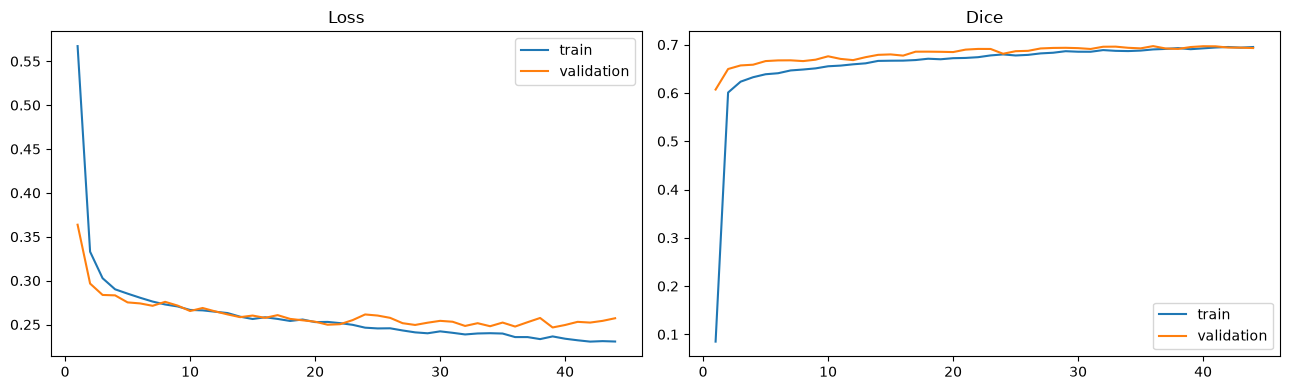

In [24]:
# Cell 18: training curves
history_df = pd.read_csv(HISTORY_PATH) if HISTORY_PATH.exists() else pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(13, 4)); axes[0].plot(history_df.epoch, history_df.train_loss, label='train'); axes[0].plot(history_df.epoch, history_df.val_loss, label='validation'); axes[0].set_title('Loss'); axes[0].legend(); axes[1].plot(history_df.epoch, history_df.train_dice, label='train'); axes[1].plot(history_df.epoch, history_df.val_dice, label='validation'); axes[1].set_title('Dice'); axes[1].legend(); plt.tight_layout(); plt.show()

In [25]:
# Cell 19: load the best checkpoint
best_checkpoint = load_checkpoint(); best_validation_dice = best_checkpoint['best_validation_dice']
print('Loaded best checkpoint from epoch:', best_checkpoint['epoch']); print('Best Validation Dice:', f'{best_validation_dice:.4f}'); print('Checkpoint image size:', best_checkpoint['image_size'])

Loaded best checkpoint from epoch: 36
Best Validation Dice: 0.6970
Checkpoint image size: 640


In [26]:
# Cell 20: final test evaluation, performed only on the best checkpoint
@torch.no_grad()
def evaluate_test():
    model.eval(); totals = {'tp': 0, 'fp': 0, 'fn': 0}; per_sample = []
    for batch in test_loader:
        logits = forward_logits(batch); target = batch['labels'].to(DEVICE)
        a, b, c = confusion_counts(logits, target); totals['tp'] += a; totals['fp'] += b; totals['fn'] += c
        for i in range(logits.shape[0]):
            x, y, z = confusion_counts(logits[i:i+1], target[i:i+1]); per_sample.append(metrics_from_counts(x, y, z)['dice'])
    return metrics_from_counts(**totals), np.asarray(per_sample)
test_metrics, test_dice_samples = evaluate_test()
print('\n' + '='*60 + '\nFINAL TEST RESULTS\n' + '='*60); print(f"Dice: {test_metrics['dice']:.4f}\nIoU: {test_metrics['iou']:.4f}\nPrecision: {test_metrics['precision']:.4f}\nRecall: {test_metrics['recall']:.4f}"); print(f'Mean per-sample Dice: {test_dice_samples.mean():.4f} +/- {test_dice_samples.std():.4f}')


FINAL TEST RESULTS
Dice: 0.6723
IoU: 0.5063
Precision: 0.6814
Recall: 0.6634
Mean per-sample Dice: 0.6266 +/- 0.1440


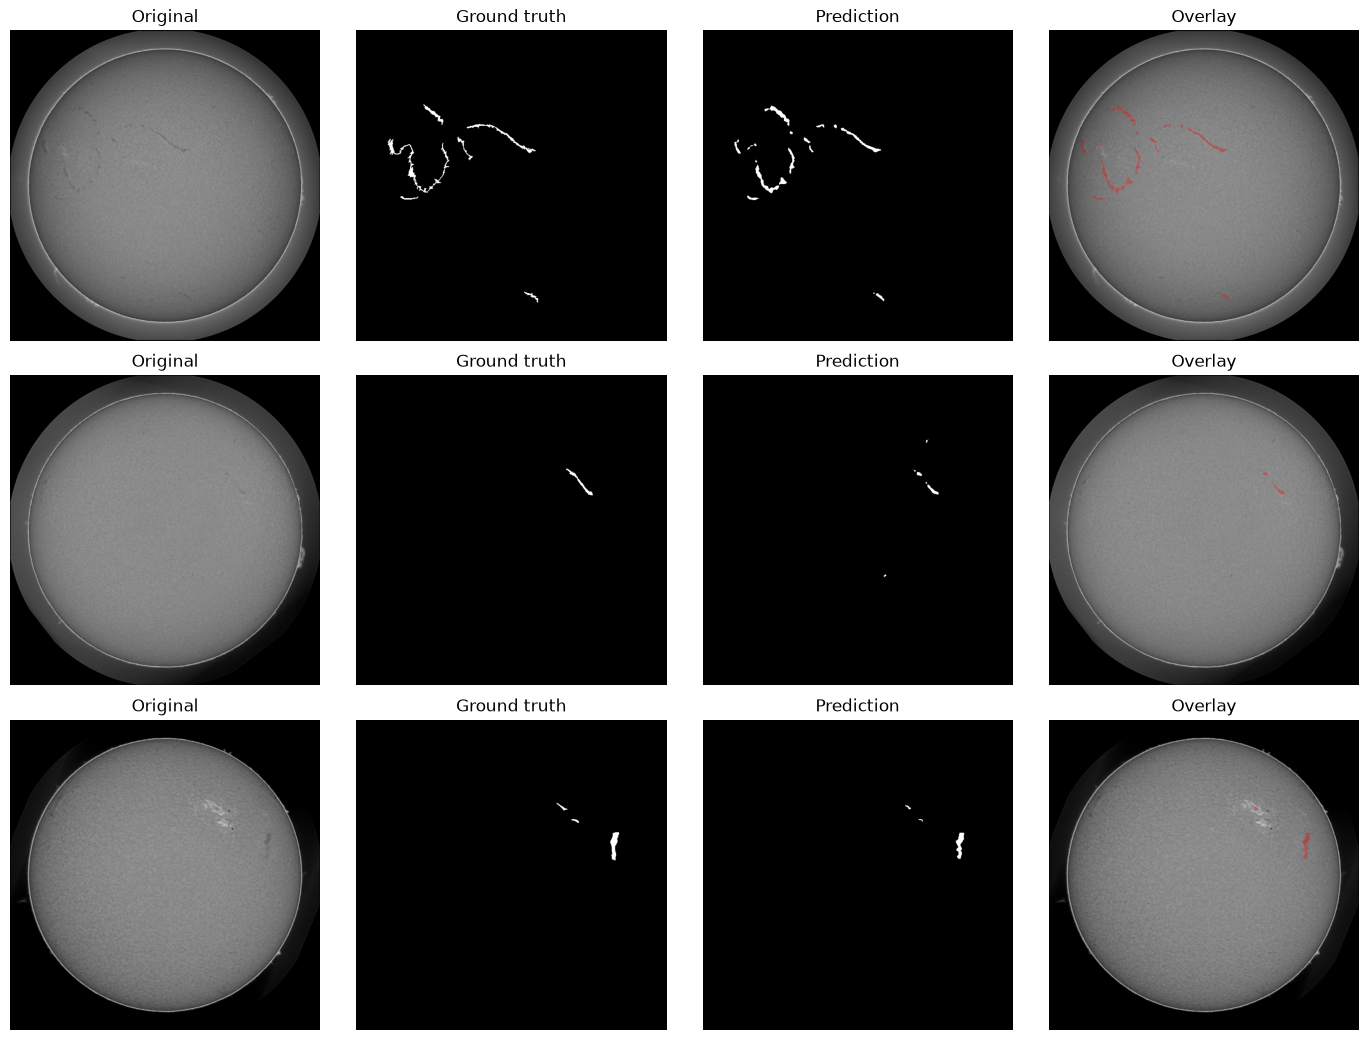

In [27]:
# Cell 21: best-checkpoint prediction visualizations
@torch.no_grad()
def show_predictions(records_to_show, columns=4):
    dataset = SolarFilamentDataset(records_to_show, IMAGE_SIZE, False); rows = len(records_to_show)
    fig, axes = plt.subplots(rows, 4, figsize=(14, 3.5 * rows), squeeze=False)
    for row, record in enumerate(records_to_show):
        item = dataset[row]; logits = forward_logits({'pixel_values': item['pixel_values'].unsqueeze(0), 'labels': item['labels'].unsqueeze(0)}); prediction = (torch.softmax(logits, dim=1)[0, 1].cpu().numpy() >= THRESHOLD)
        original = np.asarray(Image.open(record['image']).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE), Image.Resampling.BILINEAR)); truth = item['labels'].numpy().squeeze(); prediction = np.asarray(prediction).squeeze()
        overlay = original.copy(); overlay[prediction] = (0.65 * overlay[prediction] + 0.35 * np.array([255, 40, 40])).astype(np.uint8)
        for ax, data, title, cmap in zip(axes[row], [original, truth, prediction, overlay], ['Original', 'Ground truth', 'Prediction', 'Overlay'], [None, 'gray', 'gray', None]): ax.imshow(data, cmap=cmap); ax.set_title(title); ax.axis('off')
    plt.tight_layout(); plt.show()
show_predictions(val_records[:3])

In [28]:
# Cell 22: comparison with B0 and the Mask2Former benchmark
b0_validation_dice = 0.6321; benchmark = 0.72; gap_to_0_72 = benchmark - test_metrics['dice']
print('SegFormer-B0:'); print('Validation Dice = 0.6321'); print('SegFormer-B2:'); print(f'Validation Dice = {best_validation_dice:.4f}'); print('Mask2Former benchmark:'); print('Dice ~= 0.72'); print(f'gap_to_0_72 = {gap_to_0_72:.4f}'); print('Exceeds 0.72:', test_metrics['dice'] > benchmark)
print('Test threshold remained fixed at', THRESHOLD, 'and the test set was not used for model selection.')

SegFormer-B0:
Validation Dice = 0.6321
SegFormer-B2:
Validation Dice = 0.6970
Mask2Former benchmark:
Dice ~= 0.72
gap_to_0_72 = 0.0477
Exceeds 0.72: False
Test threshold remained fixed at 0.5 and the test set was not used for model selection.
